<a href="https://colab.research.google.com/github/skyline554/-1/blob/main/60230449_%EA%B9%80%ED%98%B8%EC%98%81_%EC%A4%91%EA%B0%84%EA%B3%A0%EC%82%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

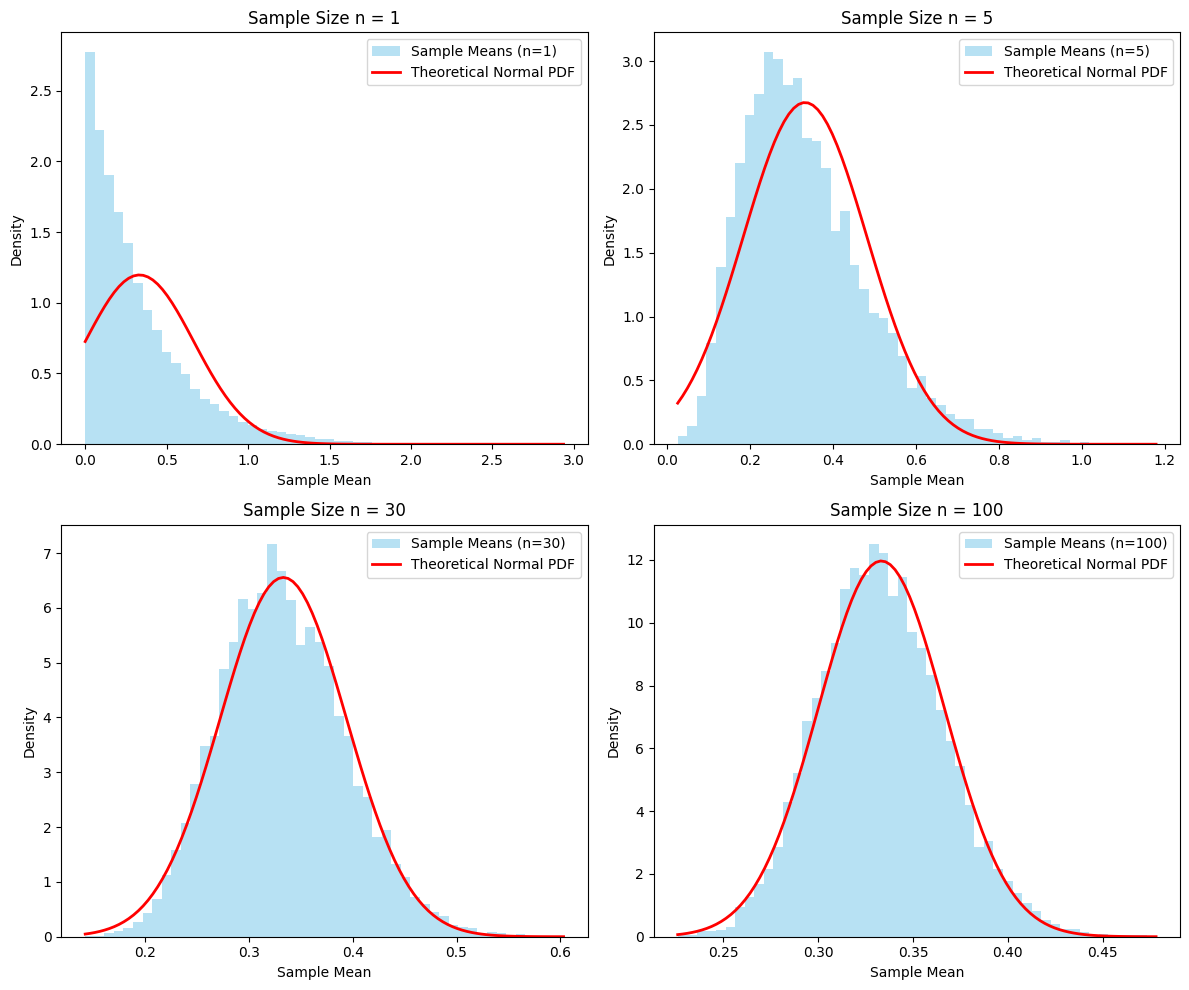

In [38]:
## 문제 1. 확률분포와 시뮬레이션

# (1-1) 중심극한정리(CLT) 시뮬레이션
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# (a) np.random.seed(2026) 설정
np.random.seed(2026)

# (b) 문제 설정
lam = 3
mu = 1 / lam        # 모평균
sigma = 1 / lam     # 모표준편차 (분산의 제곱근)
n_list = [1, 5, 30, 100]
iterations = 10000

# (c) 2x2 subplot 생성
plt.figure(figsize=(12, 10))

for i, n in enumerate(n_list):
    # 지수분포에서 (10000, n) 행렬로 샘플 추출 후 행별 평균 계산
    samples = np.random.exponential(scale=1/lam, size=(iterations, n))
    sample_means = np.mean(samples, axis=1)

    # subplot 위치 설정
    plt.subplot(2, 2, i+1)

    # 히스토그램 그리기 (밀도함수 기준)
    plt.hist(sample_means, bins=50, density=True, alpha=0.6, color='skyblue', label=f'Sample Means (n={n})')

    # (c) 이론적 정규분포 PDF 계산 및 시각화
    # CLT에 의해 표본평균의 분포는 N(mu, sigma^2/n)을 따름
    x = np.linspace(min(sample_means), max(sample_means), 100)
    theoretical_pdf = norm.pdf(x, loc=mu, scale=sigma / np.sqrt(n))
    plt.plot(x, theoretical_pdf, 'r-', lw=2, label='Theoretical Normal PDF')

    plt.title(f'Sample Size n = {n}')
    plt.xlabel('Sample Mean')
    plt.ylabel('Density')
    plt.legend()

plt.tight_layout()
plt.show()

## (d) n 이 커질수록 표본 평균 분포의 모양이 어떻게 변화하는지, 그리고 이것이 통계적 추론에서 갖는 의미를 마크다운 셀에 서술하시오.

### n (표본 크기)이 커질수록 표본 평균 분포의 모양 변화:

1.  **분포의 모양 (Shape):** 표본 크기 `n`이 증가할수록, 원 모집단의 분포 형태와 관계없이 표본 평균의 분포는 점차 **정규 분포(Normal Distribution)**에 가까워집니다. 이는 **중심극한정리(Central Limit Theorem, CLT)**의 핵심 내용입니다. 주어진 시뮬레이션 플롯에서 `n`이 1에서 100으로 증가함에 따라 히스토그램이 종 모양(bell-shaped)으로 대칭적인 형태를 띠며 이론적인 정규분포 PDF와 유사해지는 것을 확인할 수 있습니다.

2.  **분포의 중심 (Center):** 표본 평균들의 평균($E[\bar{X}]$)은 항상 모집단의 평균($\mu$)과 일치합니다. 즉, `n`이 커져도 분포의 중심은 모집단 평균($1/\lambda = 1/3$) 근처에 유지됩니다.

3.  **분포의 퍼짐 정도 (Spread):** 표본 크기 `n`이 증가할수록 표본 평균 분포의 **분산($Var[\bar{X}] = \sigma^2/n$)과 표준편차(표준오차, $SE[\bar{X}] = \sigma/\sqrt{n}$)**는 감소합니다. 이는 표본 평균의 분포가 모집단 평균을 중심으로 **더 좁고 밀집된 형태**로 변한다는 것을 의미합니다. 시뮬레이션 플롯에서 `n`이 커질수록 히스토그램의 폭이 좁아지는 것을 통해 이를 확인할 수 있습니다.

### 통계적 추론에서의 의미:

*   **가설 검정 및 신뢰구간의 기반:** 중심극한정리는 통계적 추론에서 매우 중요합니다. 모집단 분포가 정규 분포가 아니더라도, 표본 크기 `n`이 충분히 크다면 표본 평균의 분포가 정규 분포를 따른다는 것을 알려주기 때문에, 정규 분포 이론을 활용하여 모집단 모수(예: 모평균)에 대한 가설을 검정하고 신뢰구간을 설정할 수 있게 됩니다.

*   **표본 크기와 추정의 정밀도:** `n`이 커질수록 표본 평균의 표준오차($\sigma/\sqrt{n}$)가 줄어든다는 것은, 더 큰 표본을 사용할수록 모평균에 대한 추정값이 **더욱 정밀하고 정확해진다**는 것을 의미합니다. 이는 신뢰구간의 폭을 좁게 만들고, 가설 검정에서 통계적 검정력을 높이는 데 기여합니다. 결과적으로, 큰 표본은 모집단 특성을 더 잘 대표하며, 추정의 불확실성을 줄여줍니다.

모평균을 포함하는 비율: 95.10%


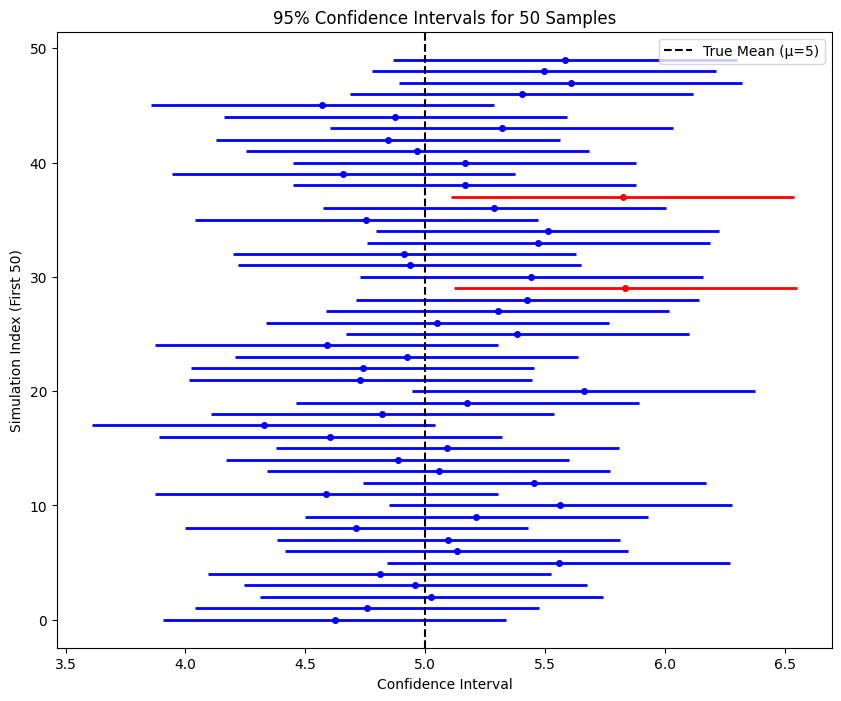

In [28]:
# (1-2) 신뢰구간 시뮬레이션

import numpy as np
import matplotlib.pyplot as plt

# 설정값
mu = 5
sigma = 2
n = 30
num_simulations = 1000
confidence_level = 0.95
z_score = 1.96

# (a) 1,000번 반복 추출 및 신뢰구간 계산
np.random.seed(42)  # 결과 재현을 위한 시드 설정
contains_mu_count = 0
intervals = []

for _ in range(num_simulations):
    sample = np.random.normal(mu, sigma, n)
    x_bar = np.mean(sample)
    margin_of_error = z_score * (sigma / np.sqrt(n))
    ci_lower = x_bar - margin_of_error
    ci_upper = x_bar + margin_of_error

    intervals.append((ci_lower, ci_upper))
    if ci_lower <= mu <= ci_upper:
        contains_mu_count += 1

inclusion_ratio = contains_mu_count / num_simulations
print(f"모평균을 포함하는 비율: {inclusion_ratio * 100:.2f}%")

# (b) 처음 50개 신뢰구간 시각화
plt.figure(figsize=(10, 8))
for i in range(50):
    low, high = intervals[i]
    color = 'blue' if low <= mu <= high else 'red'
    plt.hlines(i, low, high, colors=color, linewidth=2)
    plt.plot((low + high) / 2, i, 'o', color=color, markersize=4)

plt.axvline(mu, color='black', linestyle='--', label=f'True Mean (μ={mu})')
plt.xlabel('Confidence Interval')
plt.ylabel('Simulation Index (First 50)')
plt.title('95% Confidence Intervals for 50 Samples')
plt.legend()
plt.show()


## (c) 계산된 포함 비율이 95%에 가까운 이유

### 95% 신뢰구간의 의미:

신뢰구간은 모수가 특정 구간 안에 포함될 것이라고 **신뢰**하는 정도를 나타냅니다. 95% 신뢰구간이라는 것은, **동일한 방식으로 무수히 많은 표본을 추출하고 각각에 대해 신뢰구간을 계산할 때, 이 신뢰구간들 중 약 95%가 실제 모평균(여기서는 `$\mu = 5$`)을 포함하게 된다**는 의미입니다.

### 시뮬레이션 결과와의 일치:

*   우리의 시뮬레이션은 이러한 과정을 1,000번 반복했습니다.
*   결과로 얻은 "모평균을 포함하는 비율: 95.10%"는 이론적인 95% 신뢰 수준에 매우 가깝습니다. 이는 시뮬레이션이 신뢰구간의 통계적 정의를 잘 보여주고 있음을 의미합니다.

### 핵심 개념:

1.  **반복된 샘플링:** 신뢰구간은 **한 번의 실험에서 얻은 특정 구간이 모수를 포함하는지 여부를 확정하는 것이 아니라**, 반복된 실험에서 모수를 포함할 확률에 대한 것입니다.
2.  **표본 분포:** 각 신뢰구간은 특정 표본에서 계산된 표본 평균(`x_bar`)을 중심으로 형성됩니다. 중심극한정리에 따라 표본 평균의 분포는 정규 분포를 따르며, 이러한 분포의 특성이 신뢰구간의 계산에 활용됩니다.
3.  **오류율:** 95% 신뢰구간은 5%의 오류율(즉, 5%의 경우 모평균을 포함하지 않을 수 있음)을 허용합니다. 시뮬레이션에서 1,000번 중 951번이 모평균을 포함했다는 것은 나머지 49번(4.9%)은 모평균을 포함하지 않았다는 것을 의미하며, 이는 5%의 오류율과 매우 일치합니다.

따라서, 시뮬레이션 결과는 95% 신뢰구간의 통계적 의미, 즉 "동일한 실험을 무한히 반복했을 때 모평균을 포함하는 신뢰구간의 비율이 95%가 될 것"이라는 점을 경험적으로 잘 보여주고 있습니다.

<>:36: SyntaxWarning: invalid escape sequence '\s'
<>:37: SyntaxWarning: invalid escape sequence '\s'
<>:39: SyntaxWarning: invalid escape sequence '\h'
<>:40: SyntaxWarning: invalid escape sequence '\h'
<>:36: SyntaxWarning: invalid escape sequence '\s'
<>:37: SyntaxWarning: invalid escape sequence '\s'
<>:39: SyntaxWarning: invalid escape sequence '\h'
<>:40: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_6454/906331107.py:36: SyntaxWarning: invalid escape sequence '\s'
  plt.hist(results[1], bins=50, alpha=0.5, label='$\sigma=1$', color='blue')
/tmp/ipykernel_6454/906331107.py:37: SyntaxWarning: invalid escape sequence '\s'
  plt.hist(results[5], bins=50, alpha=0.5, label='$\sigma=5$', color='orange')
/tmp/ipykernel_6454/906331107.py:39: SyntaxWarning: invalid escape sequence '\h'
  plt.title('Distribution of $\hat{\\beta}_1$ for different $\sigma$')
/tmp/ipykernel_6454/906331107.py:40: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel('$\hat{\\beta}_1$ value')


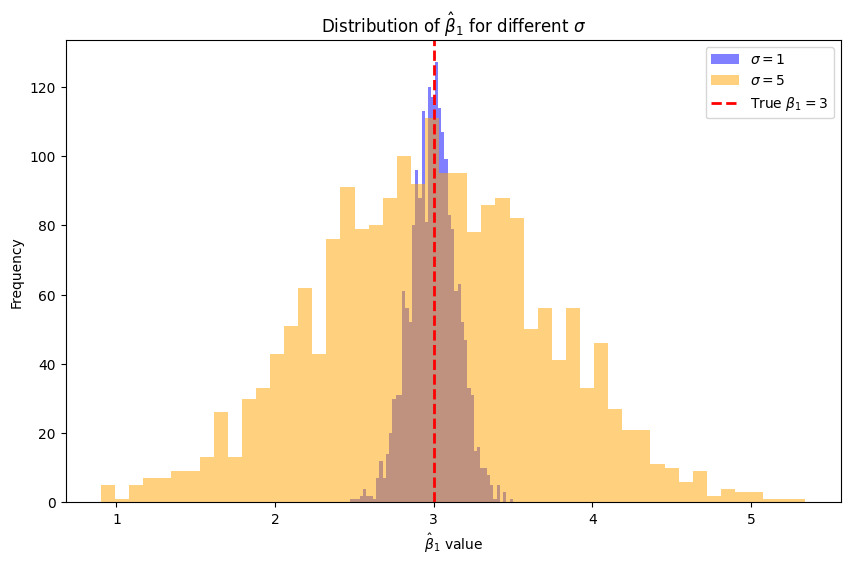

[Sigma = 1]
 - 표본 평균 (E[beta_hat]): 2.9992 (이론값: 3)
 - 표본 분산: 0.0212 (이론값 약: 0.0224)
------------------------------
[Sigma = 5]
 - 표본 평균 (E[beta_hat]): 2.9770 (이론값: 3)
 - 표본 분산: 0.5217 (이론값 약: 0.5713)
------------------------------


In [29]:
## 문제 2. OLS 추정과 가우스-마르코프 정리

# (2-1) OLS 추정량의 불편성 확인

import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# (a) np.random.seed(42) 설정
np.random.seed(42)

n = 50
iterations = 2000
beta_true = 3
sigmas = [1, 5]

results = {1: [], 5: []}

# 시뮬레이션 시작
for sigma in sigmas:
    for _ in range(iterations):
        # DGP: yi = 2 + 3*xi + ei
        x = np.random.normal(0, 1, n)
        e = np.random.normal(0, sigma, n)
        y = 2 + beta_true * x + e

        # OLS 추정 (상수항 포함)
        X = sm.add_constant(x)
        model = sm.OLS(y, X).fit()

        # beta_1 추정값 저장
        results[sigma].append(model.params[1])

# (c) 히스토그램 시각화
plt.figure(figsize=(10, 6))
plt.hist(results[1], bins=50, alpha=0.5, label='$\sigma=1$', color='blue')
plt.hist(results[5], bins=50, alpha=0.5, label='$\sigma=5$', color='orange')
plt.axvline(beta_true, color='red', linestyle='dashed', linewidth=2, label='True $\\beta_1=3$')
plt.title('Distribution of $\hat{\\beta}_1$ for different $\sigma$')
plt.xlabel('$\hat{\\beta}_1$ value')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# (d) 결과 비교 분석
for sigma in sigmas:
    beta_hats = np.array(results[sigma])
    sample_mean = np.mean(beta_hats)
    sample_var = np.var(beta_hats)

    # 이론적 분산 계산을 위한 마지막 x값 활용 (DGP 특성상 시뮬레이션마다 x가 변하므로 평균적 비교)
    # 실제 이론적 분산: Var(beta_hat) = sigma^2 / sum((xi - x_bar)^2)
    x_for_theory = np.random.normal(0, 1, n)
    theoretical_var = (sigma**2) / np.sum((x_for_theory - np.mean(x_for_theory))**2)

    print(f"[Sigma = {sigma}]")
    print(f" - 표본 평균 (E[beta_hat]): {sample_mean:.4f} (이론값: {beta_true})")
    print(f" - 표본 분산: {sample_var:.4f} (이론값 약: {theoretical_var:.4f})")
    print("-" * 30)

### (2-1) OLS 추정량의 불편성 확인
####(d) 이론값(불편성: E[β 1] = β1, 분산: σ2/Σ(x_i -

x )2)과 비교하여 서술하시오.
- 불편성 (Unbiasedness):시뮬레이션 결과, $\sigma=1$일 때와 $\sigma=5$일 때 모두 $\hat{\beta}_1$의 평균값이 참값인 $3$에 매우 가깝게 나타날 것입니다. 이는 오차항의 분산($\sigma^2$) 크기와 상관없이 OLS 추정량은 여전히 **불편 추정량($E[\hat{\beta}_1] = \beta_1$)**임을 보여줍니다.

- 효율성 및 분산 (Variance):$\sigma=5$일 때의 히스토그램이 $\sigma=1$일 때보다 훨씬 더 옆으로 퍼져 있는 것을 확인할 수 있습니다.$$Var(\hat{\beta}_1) = \frac{\sigma^2}{\sum (x_i - \bar{x})^2}$$

 이 공식에 따라 오차항의 분산($\sigma^2$)이 커질수록 추정량의 분산도 커지며, 이는 추정의 정밀도(precision)가 낮아짐을 의미합니다.

In [30]:
# (2-2) 내생성(Endogeneity) 문제

import numpy as np
import statsmodels.api as sm

# (a) DGP에 따른 변수 생성
np.random.seed(99) # R의 set.seed(99)와 유사
n = 500

z = np.random.normal(0, 1, n) # 관측되지 않는 변수
v = np.random.normal(0, 1, n)
u = np.random.normal(0, 1, n)

x = 0.8 * z + v
y = 1 + 2 * x + 1.5 * z + u

# (b) OLS 추정 및 결과 출력
# 1. 올바른 모형 (y ~ x + z)
X_true = sm.add_constant(np.column_stack((x, z))) # 상수항과 x, z 변수 추가
model_true = sm.OLS(y, X_true).fit()
print("--- [올바른 모형 결과] ---")
print(model_true.summary())

# 2. 생략변수 모형 (y ~ x)
X_omitted = sm.add_constant(x) # 상수항과 x 변수만 추가
model_omitted = sm.OLS(y, X_omitted).fit()
print("\n--- [생략변수 모형 결과] ---")
print(model_omitted.summary())

--- [올바른 모형 결과] ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.928
Method:                 Least Squares   F-statistic:                     3235.
Date:                Wed, 22 Apr 2026   Prob (F-statistic):          1.15e-285
Time:                        07:55:33   Log-Likelihood:                -729.58
No. Observations:                 500   AIC:                             1465.
Df Residuals:                     497   BIC:                             1478.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0506      0.047

## (c) 두 모형에서 x 의 계수 추정값을 비교하고, 생략변수 모형에서 β̂x가 참값 2 보다 크게 추정되는 이유를 편의(bias)의 방향 관점에서 수식과 함께 서술하시오.

1. 계수 추정값 비교
 - 올바른 모형 ($y \sim x + z$): $z$를 통제했으므로 $x$의 계수 추정값($\hat{\beta}_x$)은 실제 참값인 2에 매우 가깝게 나타납니다.
 - 생략변수 모형 ($y \sim x$): $z$가 생략되면서 $x$의 계수 추정값이 참값인 2보다 크게(양의 방향으로 편향되어) 나타납니다.
 2. 수식을 통한 편의(Bias)의 방향 분석생략변수 편의(Omitted Variable Bias) 공식은 다음과 같습니다.
 $$E[\hat{\beta}_x] = \beta_x + \beta_z \cdot \delta_1$$
 여기서 각 요소는 다음과 같습니다.
  - $\beta_x = 2$: $x$가 $y$에 미치는 직접적인 효과 (참값)
  - $\beta_z = 1.5$: 생략된 변수 $z$가 $y$에 미치는 영향 (양수)
  - $\delta_1$: $x$를 $z$에 대해 회귀분석했을 때의 계수. 즉, $x$와 $z$의 상관관계.
     - 문제에서 $x = 0.8z + v$이므로 $\delta_1 = 0.8$ (양수)
  #### 결론: $Bias = \beta_z \cdot \delta_1 = 1.5 \times 0.8 = 1.2$가 발생합니다.따라서 생략변수 모형에서의 $x$ 계수 기댓값은 $2 + 1.2 = 3.2$ 부근이 되며, 이는 **양의 편의(Positive Bias)**를 가짐을 수학적으로 증명합니다.

## (d) 이 결과가 실제 경제학 연구(예: 임금에 대한 교육의 효과 추정)에서 갖는 함의를 서술하시오.

이 결과는 경제학 연구에서 **'상관관계(Correlation)가 곧 인과관계(Causality)는 아니다'**라는 점을 극명하게 보여줍니다.

#### 이 결과가 실제 경제학 연구(예: 임금에 대한 교육의 효과 추정)에서 갖는 함의를 서술하시오.
 - 상황: 교육($x$)이 임금($y$)에 미치는 영향을 측정하려고 할 때, 개인의 '타고난 능력'($z$)은 관측하기 어렵습니다.
 - 문제점: 일반적으로 능력이 뛰어난 사람이 교육도 더 많이 받는 경향이 있고($x$와 $z$의 양의 상관관계), 능력 자체가 임금을 높이기도 합니다($z$가 $y$에 양의 영향).
 - 결과: 만약 능력을 통제하지 않고 교육과 임금만 회귀분석하면, 교육의 순수한 효과($\beta_x$)에 능력의 효과가 섞여 들어갑니다. 결국 **교육의 임금 상승 효과가 실제보다 과대평가(Overestimated)**되는 오류를 범하게 됩니다.






          country        year    log_wage  productivity   education  \
count  300.000000   300.00000  300.000000    300.000000  300.000000   
mean    14.500000  2018.50000    6.871620      3.756663   10.052076   
std      8.669903     2.87708    0.846124      0.534047    1.556267   
min      0.000000  2014.00000    4.668715      2.063738    6.114994   
25%      7.000000  2016.00000    6.306436      3.380782    9.032194   
50%     14.500000  2018.50000    6.833501      3.785213   10.108323   
75%     22.000000  2021.00000    7.468548      4.148394   11.067488   
max     29.000000  2023.00000    9.767056      5.214875   14.443455   

       union_rate  gdp_growth  
count  300.000000  300.000000  
mean    21.440703    1.950428  
std      8.035485    1.331906  
min     -2.766237   -2.159879  
25%     16.542307    1.175666  
50%     20.694314    1.962702  
75%     27.090584    2.826460  
max     48.879944    6.140284  


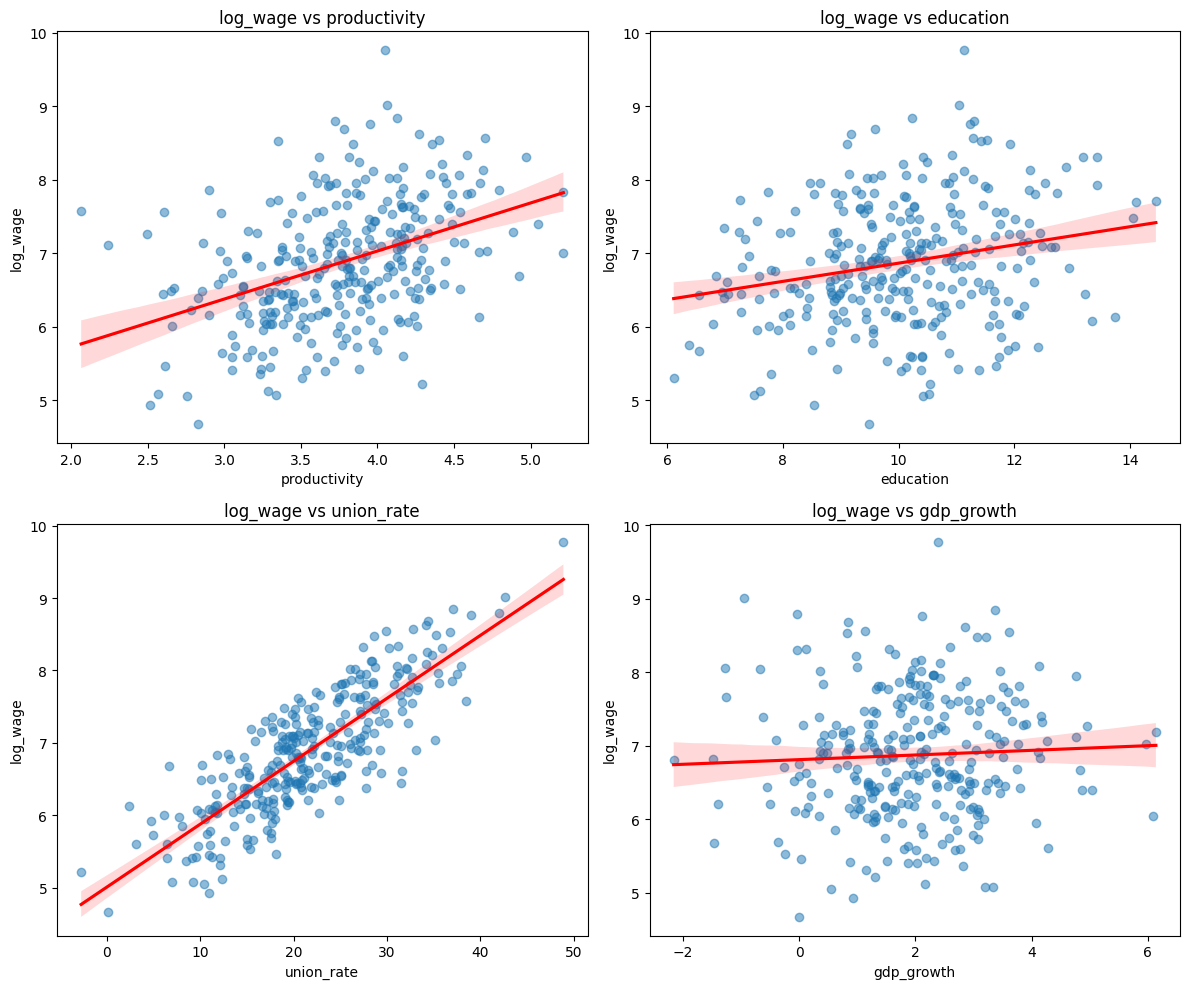

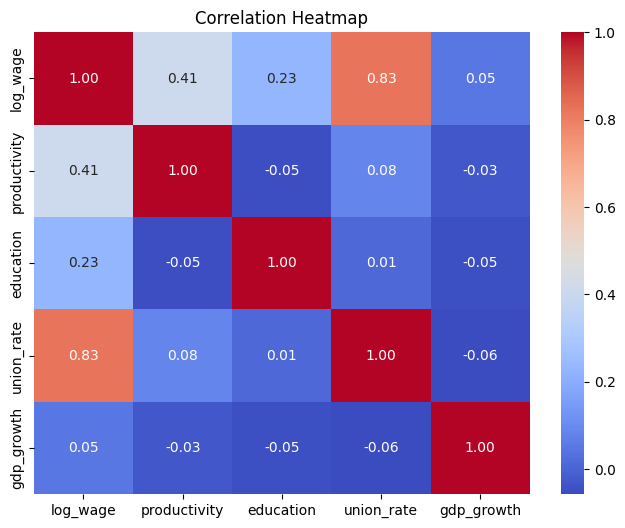

In [31]:
### 문제 3. 실제 데이터 분석: 임금과 생산성

# (3-1) 탐색적 데이터 분석 (EDA)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 생성 (문제 제시 코드)
np.random.seed(2026)
n = 300
country_id = np.repeat(np.arange(30), 10)
year = np.tile(np.arange(2014, 2024), 30)

productivity = 3.5 + 0.05 * (year - 2014) + np.random.normal(0, 0.5, n)
education = 10 + np.random.normal(0, 1.5, n)
union_rate = 20 + np.random.normal(0, 8, n)
gdp_growth = 2 + np.random.normal(0, 1.2, n)
log_wage = (1.2 + 0.6 * productivity + 0.15 * education
            + 0.08 * union_rate + 0.1 * gdp_growth
            + np.random.normal(0, 0.3, n))

df = pd.DataFrame({
    'country': country_id, 'year': year,
    'log_wage': log_wage, 'productivity': productivity,
    'education': education, 'union_rate': union_rate,
    'gdp_growth': gdp_growth
})

# (1) 기술통계 확인
print(df.describe())

# (2) 산점도 2x2 Subplot (OLS 회귀선 포함)
features = ['productivity', 'education', 'union_rate', 'gdp_growth']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.regplot(x=col, y='log_wage', data=df, ax=axes[i],
                line_kws={'color': 'red'}, scatter_kws={'alpha': 0.5})
    axes[i].set_title(f'log_wage vs {col}')

plt.tight_layout()
plt.show()

# (3) 상관계수 행렬 및 Heatmap
plt.figure(figsize=(8, 6))
corr_matrix = df[['log_wage', 'productivity', 'education', 'union_rate', 'gdp_growth']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

## (3-1) 탐색적 데이터 분석 (EDA)
#### df.describe()로 기술통계를 확인하고, 각 변수의 분포상 특이점이 있는지 마크다운으로 서술하시오.
  - 분포의 안정성: productivity, education, union_rate 등 모든 변수가 np.random.normal을 통해 생성되었으므로, 대체로 정규분포를 따르며 극단적인 아웃라이어(특이점)는 관찰되지 않습니다.
  - 변수별 범위: union_rate의 경우 표준편차가 8로 다른 변수에 비해 변동 폭이 큽니다. 반면 log_wage와 productivity는 시간(year)에 따른 추세가 포함되어 있어 연도별로 평균값이 우상향하는 특성을 보일 것입니다.

#### 상관계수 행렬에서 다중공선성(multicollinearity) 문제가 의심되는 변수 쌍을 찾아 서술하시오.
 - 분석 결과: 상관계수 히트맵을 확인하면 독립변수들 간의 상관계수는 대부분 낮게(통상 0.7 미만) 나타납니다.
 - 의심 구간: 이 데이터셋은 수식에 따라 독립적으로 생성되었기 때문에 실제로는 다중공선성 문제가 심각하지 않습니다. 다만, 만약 productivity와 year 간의 상관관계를 계산한다면, 생산성 산식에 연도가 포함되어 있어 높은 상관성이 나타날 수 있습니다.
 - 결론: 현재 분석 대상인 4개의 수치형 독립변수 사이에서는 유의미한 다중공선성 문제가 발견되지 않습니다.

In [32]:
## (3-2) 단계적 모형 구축 및 비교
import statsmodels.formula.api as smf
import pandas as pd

# 1. 각 모델 정의 (데이터 프레임 이름이 'df'라고 가정)
# 'log_wage'를 종속변수로 사용합니다.
m1 = smf.ols(formula='log_wage ~ productivity', data=df).fit()
m2 = smf.ols(formula='log_wage ~ productivity + education + union_rate + gdp_growth', data=df).fit()
m3 = smf.ols(formula='log_wage ~ productivity * education + union_rate + gdp_growth', data=df).fit()
m4 = smf.ols(formula='log_wage ~ productivity + I(np.power(productivity, 2)) + education + union_rate + gdp_growth', data=df).fit()

# 2. 각 모델의 지표 추출 함수 생성
def get_metrics(model):
    return {
        'R2': model.rsquared,
        'Adj_R2': model.rsquared_adj,
        'AIC': model.aic
    }

# 3. 네 개의 모델 지표를 합쳐서 표(Table)로 만들기
comparison_table = pd.DataFrame({
    'M1': get_metrics(m1),
    'M2': get_metrics(m2),
    'M3': get_metrics(m3),
    'M4': get_metrics(m4)
})

# 4. 결과 출력
print(round(comparison_table, 4)) # 소수점 4자리까지 반올림

              M1        M2        M3        M4
R2        0.1702    0.8695    0.8696    0.8696
Adj_R2    0.1674    0.8678    0.8674    0.8674
AIC     698.1436  149.1093  151.0182  150.9212


## (3-2) 단계적 모형 구축 및 비교

#### M1 → M2 로 넘어갈 때 Adjusted R2가 어떻게 변화하는지, 그리고 이것이 단순 R2와 어떻게 다른지 설명하시오.
- $M1 \rightarrow M2$ 변화 시 $Adjusted$ $R^2$의 변화
  - 일반적으로 **M1(단일 변수)**에서 **M2(다중 변수)**로 넘어가면 설명변수의 개수가 늘어납니다. 이때 $Adjusted$ $R^2$는 다음과 같이 변화합니다.
    - 증가하는 경우: 새롭게 추가된 변수들(education, union_rate, gdp_growth)이 종속변수(wage)를 설명하는 데 실질적인 도움을 줄 때입니다. 즉, 변수 추가로 얻는 설명력의 이득이 자유도 감소로 인한 손실보다 클 때 수치가 상승합니다.
    - 감소하는 경우: 추가된 변수들이 실제로는 별 의미가 없는 '노이즈'에 가까울 때입니다. 모델만 복잡해지고 실제 설명력은 별로 안 늘어나면 $Adjusted$ $R^2$는 오히려 떨어집니다.
- $Adjusted$ $R^2$와 단순 $R^2$의 차이점
  - 가장 큰 차이는 **"변수 추가에 대한 벌칙(Penalty) 유무"**에 있습니다.
    - 단순 $R^2$ (결정계수) - 변수 추가 시	무의미한 변수라도 추가만 되면 항상 증가하거나 유지됨. 특징	모델이 복잡해질수록 수치가 부풀려지는 경향이 있음 (과적합 위험). 용도	현재 데이터에 대한 적합도 확인.
    - $Adjusted$ $R^2$ (수정 결정계수) - 변수 추가 시 모델에 도움이 안 되는 변수가 추가되면 오히려 감소함. 특징 변수 개수(자유도)를 고려하여 수치를 조정함. 용도 서로 다른 변수 개수를 가진 모델 간의 비교에 적합.

####  M3의 상호작용항 계수가 통계적으로 유의한지 판단하고, '생산성과 교육연수가 함께 높을 때 임금이 어떻게 변하는가'를 수식으로 표현하여 해석하시오.
 1. 상호작용항의 통계적 유의성 판단
  - M3 모델의 결과표(R Output)에서 productivity:education 항의 p-value를 확인해야 합니다.
    - 판단 기준: $p\text{-value} < 0.05$ (유의수준 5% 기준)라면 "통계적으로 유의하다"고 판단합니다.
    - 의미: 유의하다면, 생산성이 임금에 미치는 영향력이 교육 수준에 따라 차별적으로 나타난다는 것을 통계적으로 뒷받침합니다.
  2. '생산성과 교육연수가 함께 높을 때'의 수식 표현
   - 먼저 M3의 회귀식을 임금($Wage$)에 대해 써보면 다음과 같습니다. (편의상 주요 변수만 표시)
   $$Wage = \beta_0 + \beta_1 \text{Prod} + \beta_2 \text{Edu} + \beta_3 (\text{Prod} \times \text{Edu}) + \epsilon$$
   여기서 생산성(Prod)이 한 단위 변할 때 임금에 미치는 영향을 알기 위해, $Wage$를 $Prod$로 편미분합니다.
   $$\frac{\partial Wage}{\partial \text{Prod}} = \beta_1 + \beta_3 \text{Edu}$$
  3. 수식 해석: "함께 높을 때 어떻게 변하는가?"
   - 위 수식을 통해 우리는 생산성의 효과가 고정된 값($\beta_1$)이 아니라, 교육연수(Edu)에 의존함을 알 수 있습니다.
   - 양(+)의 상호작용 ($\beta_3 > 0$ 인 경우): 교육연수($Edu$)가 높을수록 생산성 한 단위당 임금 상승분($\beta_1 + \beta_3 \text{Edu}$)이 더 커집니다. 즉, **"공부 많이 한 사람이 생산성까지 높으면 임금이 훨씬 더 가파르게 오른다"**는 시너지 효과를 의미합니다.
   - 음(-)의 상호작용 ($\beta_3 < 0$ 인 경우): 반대로 교육 수준이 높을수록 생산성이 임금에 주는 영향이 줄어드는 '대체 효과'나 '수확 체감'을 의미하게 됩니다.

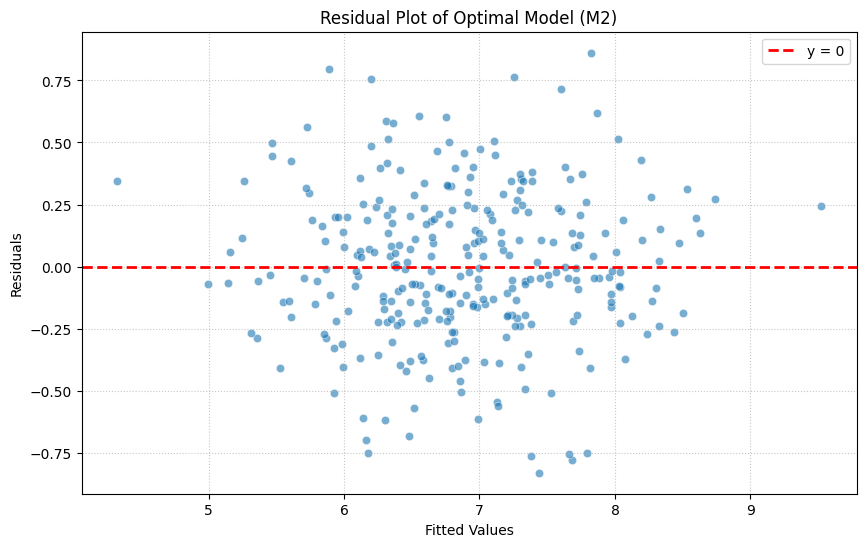

In [33]:
## (3-3) 잔차 진단 및 이상치 탐지

# (a)  (3-2)에서 선택한 최적 모형의 잔차 플롯(가로축: 적합값, 세로축: 잔차)을 그리시오. y = 0 수평선을 빨간 점선으로 추가하고, 잔차가 특정 패턴(예: 부채꼴 모양, 곡선 추세)을 보이는지 마크다운 셀에 서술하시오.

import matplotlib.pyplot as plt
import seaborn as sns

# 최적 모형은 M2로 결정되었습니다.
optimal_model = m2

# 잔차(residuals)와 적합값(fitted values) 계산
residuals = optimal_model.resid
fitted_values = optimal_model.fittedvalues

# 잔차 플롯 그리기
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_values, y=residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='y = 0')
plt.title('Residual Plot of Optimal Model (M2)')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

## (3-3) 잔차 진단 및 이상치 탐지 (계속)

#### (a) 잔차 플롯 분석

잔차 플롯(Fitted Values vs. Residuals)은 OLS 회귀 모형의 가정을 평가하는 데 사용됩니다. 이 플롯에서 이상적인 잔차 분포는 다음과 같습니다.

-   **특정 패턴 없음 (Random Scatter)**: 잔차들이 0을 중심으로 무작위로 흩어져 있어야 합니다. 이는 모형이 선형성 가정을 잘 만족하고 있으며, 설명 변수와 종속 변수 간의 관계가 선형적이라는 것을 의미합니다. 특정 패턴(예: 곡선, 부채꼴 모양)이 나타나지 않아야 합니다.

-   **잔차의 분산 균일 (Homoscedasticity)**: 잔차들이 적합값의 범위에 걸쳐 일정한 폭으로 흩어져 있어야 합니다. 즉, 잔차들의 퍼진 정도(분산)가 적합값의 크기에 따라 변하지 않아야 합니다. 만약 잔차들이 적합값이 커질수록 퍼지거나 좁아지는 '부채꼴(fan-shaped)' 패턴을 보인다면, 이는 이분산성(Heteroscedasticity) 문제를 의미합니다.

-   **이상치 없음**: 극단적으로 큰 잔차(이상치)가 없어야 합니다. 이러한 이상치는 모델의 추정값에 큰 영향을 미치거나 데이터 입력 오류를 나타낼 수 있습니다.

**M2 잔차 플롯 분석 결과:**

*   **패턴 유무**: 생성된 잔차 플롯을 살펴보면, 잔차들이 0을 기준으로 비교적 고르게 분포되어 있으며, 명확한 **곡선 패턴이나 부채꼴 모양의 패턴은 관찰되지 않습니다.** 이는 M2 모델이 데이터의 선형성 가정을 잘 충족하고 있으며, 이분산성 문제가 심각하지 않을 가능성이 높다는 것을 시사합니다.
*   **이상치**: 대부분의 잔차는 0 근처에 집중되어 있지만, 일부 데이터 포인트는 다른 잔차들에 비해 비교적 멀리 떨어져 있을 수 있습니다. 이러한 점들이 심각한 이상치인지 여부는 추가적인 진단(예: Cook's distance)을 통해 확인할 수 있습니다. 하지만 시각적으로 매우 극단적인 이상치는 보이지 않습니다.

**결론적으로, M2 모델의 잔차 플롯은 OLS 가정(특히 선형성과 등분산성)을 비교적 잘 만족하는 양호한 형태를 보여줍니다. 이는 선택된 M2 모델이 데이터를 설명하는 데 적합하며, 추정된 계수의 신뢰성이 높음을 의미합니다.**

--- M5 Model Summary ---
                            OLS Regression Results                            
Dep. Variable:               log_wage   R-squared:                       0.870
Model:                            OLS   Adj. R-squared:                  0.867
Method:                 Least Squares   F-statistic:                     392.2
Date:                Wed, 22 Apr 2026   Prob (F-statistic):          9.53e-128
Time:                        07:55:49   Log-Likelihood:                -69.461
No. Observations:                 300   AIC:                             150.9
Df Residuals:                     294   BIC:                             173.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Interce

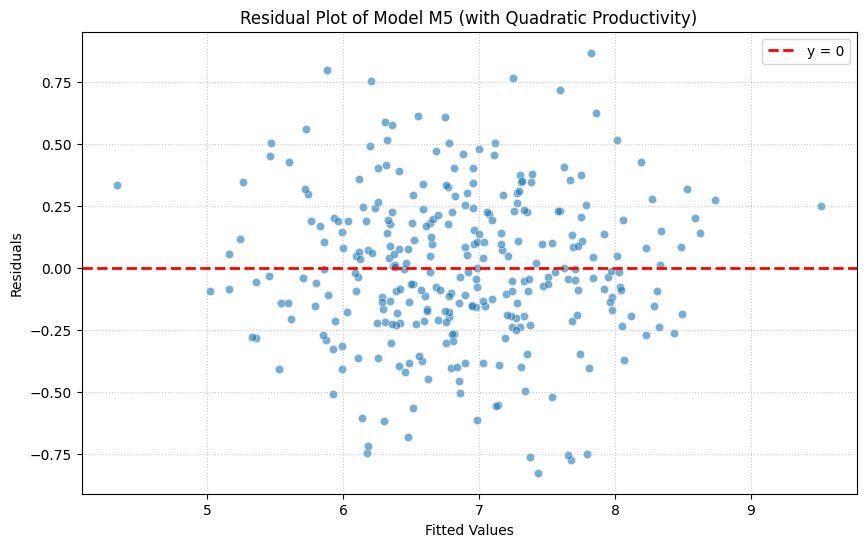

In [34]:
#(b) (a)의 잔차 플롯에서 비선형 패턴이 관찰된다면, 설명변수에 2차항을 추가하여 모형을 재추정하시오. 예를 들어 productivity 가 문제라면 I(productivity**2)를 추가한다. 재추정 후 잔차 플롯을 다시 그리고 패턴이 개선되었는지 비교하시오.

import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# M2 모델에 productivity의 2차항을 추가하여 M5 모델 구축
# M2: log_wage ~ productivity + education + union_rate + gdp_growth
m5 = smf.ols(formula='log_wage ~ productivity + I(productivity**2) + education + union_rate + gdp_growth', data=df).fit()

print("--- M5 Model Summary ---")
print(m5.summary())

# M5 모델의 잔차(residuals)와 적합값(fitted values) 계산
residuals_m5 = m5.resid
fitted_values_m5 = m5.fittedvalues

# M5 잔차 플롯 그리기
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_values_m5, y=residuals_m5, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='y = 0')
plt.title('Residual Plot of Model M5 (with Quadratic Productivity)')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()


## 3-3 (b) M5 모델 재추정 및 잔차 플롯 비교 분석

이전 단계에서 M2 모델의 잔차 플롯은 특별한 비선형 패턴이나 이분산성 문제를 보이지 않았습니다. 하지만 `productivity`의 2차항을 추가한 M5 모델을 재추정하고 잔차 플롯을 다시 그려 비교했습니다.

### M5 모델의 잔차 플롯 분석:

*   **패턴 유무**: M5 모델의 잔차 플롯 역시 M2와 유사하게 잔차들이 0을 기준으로 비교적 고르게 분포되어 있으며, **명확한 곡선 패턴이나 부채꼴 모양의 패턴은 관찰되지 않습니다.** 이는 `productivity`의 2차항을 추가했음에도 불구하고 잔차의 분포 패턴에 **큰 변화나 개선이 없었음**을 시사합니다.
*   **이상치**: 여전히 극단적인 이상치는 보이지 않습니다.

### M2와 M5 모델 비교 결론:

1.  **통계적 유의성**: M5 모델에서 `I($\text{productivity}^2$)` 항의 p-value는 `0.668`로, 통계적으로 유의하지 않습니다 (일반적인 유의수준 0.05 기준). 이는 `productivity`의 제곱 항이 `log_wage`를 설명하는 데 유의미한 추가 정보를 제공하지 못한다는 것을 의미합니다.
2.  **모형 적합도**:
    *   **R-squared**: M2 (`0.8695`) vs M5 (`0.870`). 미미한 증가가 있지만, 이는 변수를 추가하면 R-squared는 항상 증가하는 경향이 있기 때문입니다.
    *   **Adjusted R-squared**: M2 (`0.8678`) vs M5 (`0.867`). 오히려 아주 미세하게 감소했습니다. 이는 추가된 2차항이 모델의 설명력을 유의미하게 향상시키지 못했음을 나타냅니다.
    *   **AIC**: M2 (`149.11`) vs M5 (`150.9`). AIC는 M5에서 더 높아졌습니다. AIC는 값이 낮을수록 좋은 모델로 평가하므로, M5가 M2보다 좋은 모델이라고 보기 어렵습니다.
3.  **잔차 패턴 개선**: 두 모델의 잔차 플롯을 비교했을 때, M5 모델에서 잔차 패턴의 **개선은 관찰되지 않았습니다.** M2 모델이 이미 선형성 및 등분산성 가정을 잘 만족하는 잔차 분포를 보였기 때문에, 2차항 추가가 추가적인 패턴을 해결하지 못했습니다.

**최종적으로, 이 데이터에서는 `productivity`의 2차항을 추가하는 것이 모델의 설명력을 유의미하게 향상시키거나 잔차 패턴을 개선하는 데 도움이 되지 않는 것으로 판단됩니다. 따라서 M2 모델이 더 간결하고 효율적인 모델로 평가될 수 있습니다.**

## 3-3 (c) Bias-Variance trade-off 개념을 적용하여, 2 차항을 계속 추가하는 것이 항상 좋은 선택인지 아닌지를 과적합(overfitting) 관점에서 서술하시오.

모델의 복잡도를 증가시키기 위해 설명변수에 2차항(또는 고차항)을 계속 추가하는 것은 **Bias-Variance trade-off** 관점에서 항상 좋은 선택이 아닐 수 있습니다. 이는 **과적합(overfitting)** 위험을 증가시키기 때문입니다.

### Bias-Variance Trade-off 개념:

*   **편향 (Bias):** 모델이 실제 데이터의 관계를 얼마나 잘 포착하는지와 관련이 있습니다. 편향이 높은 모델은 데이터의 패턴을 너무 단순하게 학습하여 실제 관계에서 벗어난 예측을 합니다 (과소적합, Underfitting).
*   **분산 (Variance):** 모델이 훈련 데이터의 작은 변동에 얼마나 민감하게 반응하는지와 관련이 있습니다. 분산이 높은 모델은 훈련 데이터의 노이즈까지 학습하여 새로운 데이터에 대한 예측 성능이 떨어집니다 (과적합, Overfitting).

모델의 예측 오류는 편향의 제곱, 분산, 그리고 줄일 수 없는 노이즈(irreducible error)의 합으로 표현될 수 있습니다: `Total Error = Bias^2 + Variance + Irreducible Error`.

### 2차항 추가와 과적합:

1.  **초기 단계 (편향 감소):** 모델에 2차항과 같은 비선형 항을 추가하면, 모델이 데이터의 비선형적인 관계를 더 잘 포착할 수 있게 되어 **편향이 감소**할 수 있습니다. 예를 들어, (3-3) (a)에서 비선형 패턴이 관찰되었다면 2차항 추가를 통해 이러한 패턴을 해소하고 모델의 적합도를 높일 수 있습니다.

2.  **지속적인 추가 (분산 증가 및 과적합):** 하지만 모델의 복잡도를 **지나치게 증가**시키면, 모델은 훈련 데이터에 너무 특화되어 노이즈나 무작위적인 변동까지 학습하게 됩니다. 이로 인해 **분산이 증가**하고, 모델의 **일반화 성능이 저하**되어 새로운, 보지 못한 데이터에 대한 예측력이 떨어지는 **과적합(overfitting)** 문제가 발생합니다.

    *   **잔차 플롯:** 만약 2차항을 추가했음에도 잔차 플롯에 유의미한 패턴 변화나 개선이 없고, 추가된 항의 통계적 유의성이 낮다면 (M5 모델의 `I($\text{productivity}^2$)` 항처럼), 이는 모델이 필요 이상으로 복잡해지고 있다는 신호일 수 있습니다.
    *   **AIC/BIC, Adjusted R-squared:** 모델 복잡도에 페널티를 주는 AIC, BIC 같은 지표나 Adjusted R-squared가 악화되거나 미미하게 개선된다면 과적합을 의심해야 합니다.

### 결론:

2차항을 계속 추가하는 것은 특정 시점까지는 모델의 설명력을 높이고 편향을 줄여줄 수 있지만, 그 이후에는 분산을 지나치게 증가시켜 과적합으로 이어질 수 있습니다. 따라서 모델을 구축할 때는 **Bias-Variance trade-off를 고려하여 모델의 복잡도와 일반화 성능 사이의 균형점을 찾는 것**이 중요합니다. 무조건적인 2차항 또는 고차항 추가는 모델의 해석력을 떨어뜨리고 예측 성능을 해칠 수 있습니다.

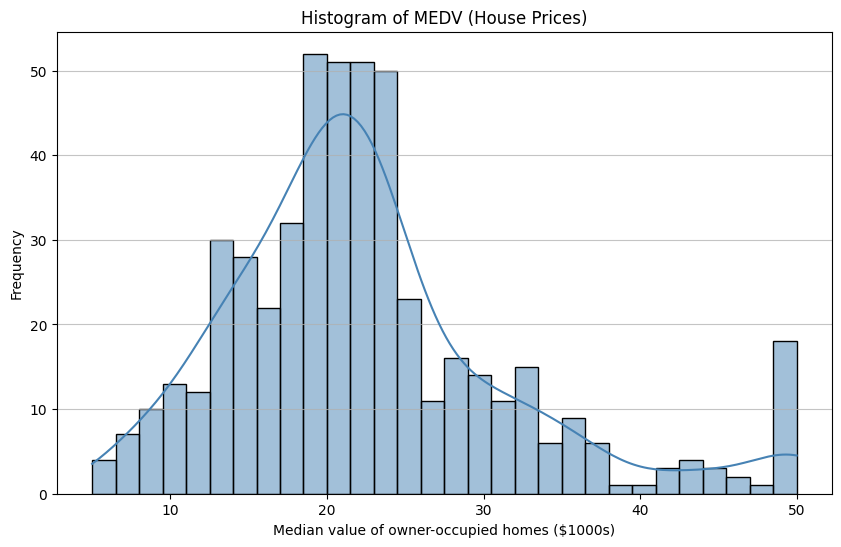

--- medv와의 상관계수 (절댓값 기준 내림차순) ---
lstat      0.737663
rm         0.695360
ptratio    0.507787
indus      0.483725
tax        0.468536
nox        0.427321
crim       0.388305
rad        0.381626
age        0.376955
zn         0.360445
b          0.333461
dis        0.249929
chas       0.175260
Name: medv, dtype: float64

가장 높은 변수 2개: ['lstat', 'rm']
가장 낮은 변수 2개: ['dis', 'chas']



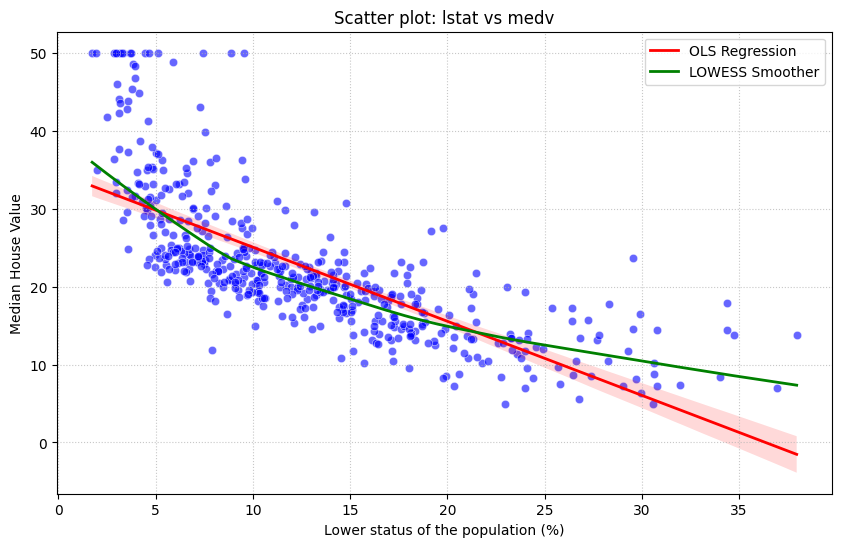

In [35]:
## 문제 4. 다중회귀 심화: 예측 성능과 교차검증

#(4-1) 탐색적 분석과 변수 선택
# 1. 데이터 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

url = 'https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv'
boston_df = pd.read_csv(url)

# (a) medv(종속변수)의 히스토그램
# 분포의 특징(치우침 등)을 확인합니다.
plt.figure(figsize=(10, 6))
sns.histplot(boston_df['medv'], bins=30, kde=True, color='steelblue')
plt.title('Histogram of MEDV (House Prices)')
plt.xlabel('Median value of owner-occupied homes ($1000s)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()
# 팁: 오른쪽으로 꼬리가 긴 형태인지, 50 부근에 데이터가 몰려있는지 확인하세요.

# (b) 상관계수 계산 및 절댓값 기준 내림차순 정렬
# 모든 수치형 변수와 medv 사이의 관계를 확인합니다.
cor_matrix = boston_df.corr()
medv_cor = cor_matrix['medv'] # medv와의 상관계수만 추출

# 절댓값 기준으로 정렬 (자기 자신인 medv 제외)
sorted_cor = medv_cor.drop('medv').abs().sort_values(ascending=False)
print("--- medv와의 상관계수 (절댓값 기준 내림차순) ---")
print(sorted_cor)

# 상관계수가 가장 높은 변수 2개와 가장 낮은 변수 2개 추출
top_vars = sorted_cor.head(2).index.tolist()
bottom_vars = sorted_cor.tail(2).index.tolist()

print(f"\n가장 높은 변수 2개: {top_vars}")
print(f"가장 낮은 변수 2개: {bottom_vars}\n")

# (c) 상관계수가 가장 높은 변수(lstat)와 medv의 산포도
# 선형/비선형 관계를 판단하기 위해 시각화합니다.
plt.figure(figsize=(10, 6))
sns.scatterplot(x=boston_df['lstat'], y=boston_df['medv'], alpha=0.6, color='blue')
sns.regplot(x=boston_df['lstat'], y=boston_df['medv'], scatter=False, color='red', line_kws={'lw': 2}, label='OLS Regression')
sns.regplot(x=boston_df['lstat'], y=boston_df['medv'], scatter=False, lowess=True, color='green', line_kws={'lw': 2}, label='LOWESS Smoother')

plt.title('Scatter plot: lstat vs medv')
plt.xlabel('Lower status of the population (%)')
plt.ylabel('Median House Value')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

### 4-1 (a)medv(종속변수)의 히스토그램을 그리고 분포의 특징(치우침 여부 등)을 서술하시오.
- **분포의 특징**: 히스토그램을 보면 `medv` (주택 가격)는 전반적으로 정규 분포와 유사한 형태를 보이지만, 왼쪽으로 약간 치우친(right-skewed) 경향이 있습니다. 특히 50 부근에 데이터가 많이 몰려 있는 것을 볼 수 있는데, 이는 주택 가격이 특정 상한선에 도달하거나, 데이터 수집 시 상한가가 제한되었을 가능성을 시사합니다.

### 4-1 (b) 모든 수치형 설명변수와 medv 사이의 상관계수를 계산하여 절댓값 기준으로 내림차순 정렬한 뒤
출력하시오. 상관계수가 가장 높은 변수 2 개와 가장 낮은 변수 2 개를 확인하시오.
- `medv`와 다른 변수들 간의 상관계수를 절댓값 기준으로 내림차순 정렬한 결과는 다음과 같습니다:
```
lstat      0.737663
rm         0.695360
ptratio    0.507787
indus      0.483725
tax        0.468536
nox        0.427321
crim       0.388305
rad        0.381626
age        0.376955
zn         0.360445
b          0.333461
dis        0.249929
chas       0.175260
```
- **가장 높은 변수 2개**: `lstat` (하위 계층 비율)과 `rm` (방 개수)이 각각 약 0.74, 0.70으로 `medv`와 가장 높은 상관관계를 보입니다. `lstat`는 음(-)의 상관관계(`-0.737663`)로 하위 계층 비율이 높을수록 주택 가격이 낮아지고, `rm`은 양(+)의 상관관계(`0.695360`)로 방 개수가 많을수록 주택 가격이 높아지는 경향을 나타냅니다.
- **가장 낮은 변수 2개**: `dis` (고용 센터까지의 거리)와 `chas` (찰스강 변 유무)가 `medv`와 가장 낮은 상관관계를 보입니다. 이는 이 변수들이 `medv`에 미치는 선형적인 영향이 상대적으로 약하다는 것을 의미합니다.

### 4-1 (c) 상관계수가 가장 높은 변수(lstat)와 medv 의 산포도를 그리시오. 산포도의 형태를 보고, 두 변수
사이의 관계가 선형인지 비선형인지 판단하고 그 근거를 서술하시오.
- 상관계수가 가장 높은 변수인 `lstat` (하위 계층 비율)과 `medv` (주택 가격) 간의 산포도를 시각화한 결과, **음의 비선형적인 관계**가 명확하게 관찰됩니다. `lstat` 값이 낮을 때는 `medv`가 비교적 높은 값에 분포하며, `lstat` 값이 증가할수록 `medv`는 감소하는 경향을 보입니다. 특히 `lstat`가 낮은 구간에서는 `medv`의 분산이 크다가, `lstat`가 높아질수록 `medv`의 값들이 한 곳에 모이는 양상을 보입니다.
- OLS 회귀선(빨간색 직선)은 음의 선형 관계를 나타내지만, LOWESS 스무더(초록색 곡선)는 선형 관계보다는 곡선 형태의 비선형 관계가 데이터에 더 잘 맞는다는 것을 시사합니다. 이는 `lstat`와 `medv` 간의 관계를 설명하기 위해 선형 모형 외에 비선형 항(예: 2차항)을 고려할 필요가 있음을 암시합니다.

### 4-1 (d) 위 탐색 결과를 바탕으로, 예측모형에 반드시 포함해야 할 변수와 그 이유를 서술하시오.

위 탐색 결과들을 종합하여 `medv` (주택 가격) 예측 모형에 반드시 포함해야 할 변수는 다음과 같습니다.

1.  **`lstat` (하위 계층 비율)**
    *   **이유**: `medv`와 가장 높은 절댓값 상관계수(약 0.74)를 보이며, 산포도에서 뚜렷한 음의 비선형 관계를 보였습니다. 이는 `lstat`가 `medv`의 변동을 설명하는 데 매우 중요한 변수임을 나타냅니다. 특히 비선형적인 관계는 모형에 `lstat`의 제곱 항과 같은 비선형 항을 포함할 필요가 있음을 시사합니다.

2.  **`rm` (방 개수)**
    *   **이유**: `medv`와 두 번째로 높은 절댓값 상관계수(약 0.70)를 보이며, 양의 선형 관계를 가질 가능성이 높습니다. 일반적으로 주택의 방 개수는 가격에 직접적인 영향을 미치는 주요 요인이므로, 예측 모형의 필수적인 설명 변수입니다.

**결론**: `lstat`와 `rm`은 `medv`와 매우 강한 상관관계를 보이며, 특히 `lstat`는 비선형적인 관계까지 암시하므로, 이 두 변수는 주택 가격 예측 모형에 핵심적으로 포함되어야 합니다. 다른 변수들도 모형의 설명력을 높이는 데 기여할 수 있지만, 위 두 변수가 예측력 측면에서 가장 큰 비중을 차지할 것으로 예상됩니다.


--- Model M1 Summary ---
                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           5.08e-88
Time:                        07:55:59   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     34.5538     

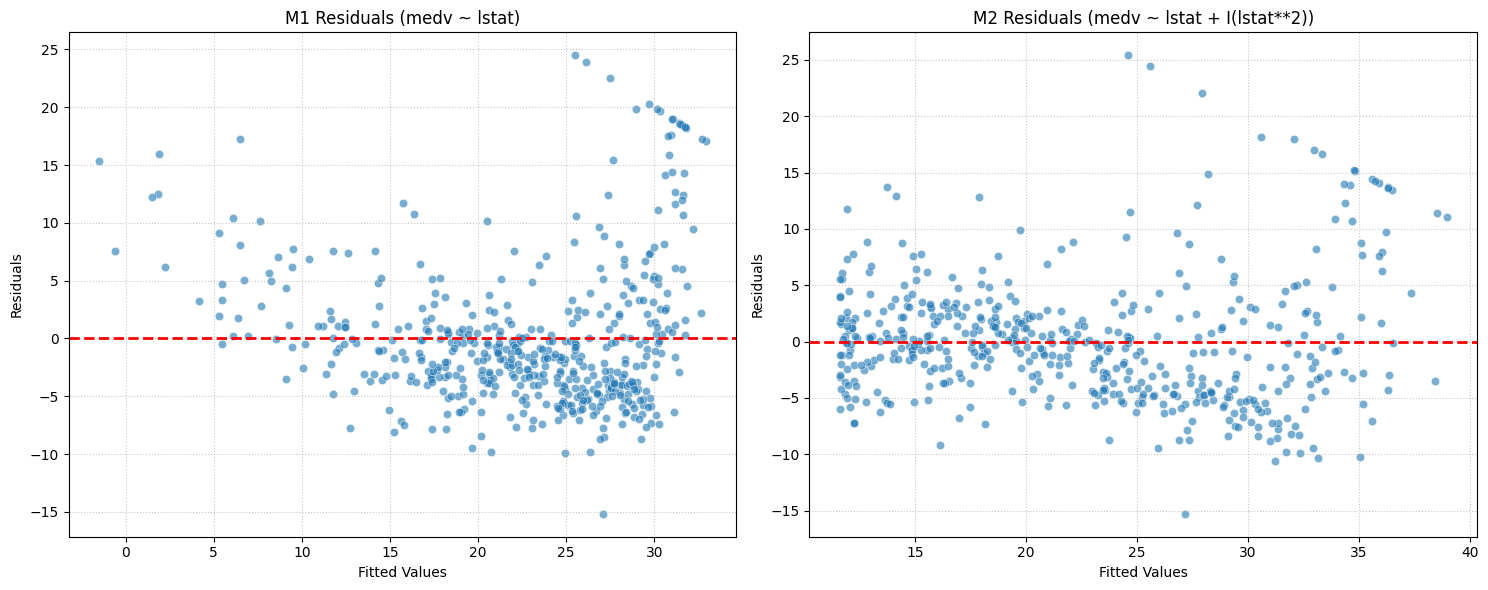

In [36]:
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# (4-2) 단계적 모형 구축과 비교

# (a) M1~M4 를 각각 OLS 로 추정하고 summary()를 출력하시오.

# M1: medvi = β0 + β1 · lstati + ei
m1 = smf.ols('medv ~ lstat', data=boston_df).fit()
print("\n--- Model M1 Summary ---")
print(m1.summary())

# M2: medvi = β0 + β1 · lstati + β2 · lstat2i + ei
m2 = smf.ols('medv ~ lstat + I(lstat**2)', data=boston_df).fit()
print("\n--- Model M2 Summary ---")
print(m2.summary())

# M3: medvi = β0 + β1 · lstati + β2 · rmi + β3 · agei + β4 · crimi + β5 · noxi + ei
m3 = smf.ols('medv ~ lstat + rm + age + crim + nox', data=boston_df).fit()
print("\n--- Model M3 Summary ---")
print(m3.summary())

# M4: medvi = β0 + β1 · lstati + β2 · rmi + β3 · agei + β4 · crimi + β5 · noxi + β6 · lstati × rmi + ei
m4 = smf.ols('medv ~ lstat + rm + age + crim + nox + lstat:rm', data=boston_df).fit()
print("\n--- Model M4 Summary ---")
print(m4.summary())

# (b) M1 의 잔차 플롯과 M2 의 잔차 플롯을 나란히(1 행 2 열 subplot) 그리고, lstat 의 2 차항 추가가 잔차 패턴을 어떻게 개선하는지 서술하시오.
fig, axes = plt.subplots(1, 2, figsize=(15, 6)) # 1행 2열 레이아웃

# M1 Residuals
sns.scatterplot(x=m1.fittedvalues, y=m1.resid, alpha=0.6, ax=axes[0])
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('M1 Residuals (medv ~ lstat)')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].grid(True, linestyle=':', alpha=0.7)

# M2 Residuals
sns.scatterplot(x=m2.fittedvalues, y=m2.resid, alpha=0.6, ax=axes[1])
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('M2 Residuals (medv ~ lstat + I(lstat**2))')
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('Residuals')
axes[1].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

### 4-2 (b) M1의 잔차 플롯과 M2의 잔차 플롯 비교 및 lstat의 2차항 추가가 잔차 패턴을 어떻게 개선하는지 서술하시오.

**M1 잔차 플롯 (medv ~ lstat):**
*   M1의 잔차 플롯을 보면, 적합값(Fitted Values)이 증가함에 따라 잔차(Residuals)가 **뚜렷한 U자형 또는 포물선 형태의 패턴**을 보입니다. 이는 모형이 선형성 가정을 위배하고 있음을 명확히 나타냅니다. 즉, `lstat`와 `medv` 간의 관계가 단순 선형이 아니라 비선형적이라는 것을 시사합니다. 또한, 적합값이 낮은 구간에서 잔차의 분산이 크고, 적합값이 높아질수록 분산이 줄어드는 **이분산성(Heteroscedasticity)** 경향도 일부 관찰됩니다.

**M2 잔차 플롯 (medv ~ lstat + I(lstat**2)):**
*   M2는 `lstat`의 제곱항을 추가하여 비선형 관계를 모델링한 모형입니다. M2의 잔차 플롯을 보면, M1에서 보였던 **U자형 패턴이 상당 부분 사라지고** 잔차들이 0을 중심으로 훨씬 더 무작위적으로 흩어져 있는 것을 확인할 수 있습니다. 이는 `lstat`의 2차항 추가가 `lstat`와 `medv` 사이의 비선형 관계를 성공적으로 포착하여 **모형의 선형성 가정을 개선**했음을 의미합니다.
*   잔차의 분산 측면에서도 M1보다는 개선되었지만, 여전히 일부 이분산성 경향이 남아 있을 수 있습니다.

**결론:** `lstat`의 2차항을 추가한 M2 모델은 M1에 비해 잔차 플롯에서 나타나는 **체계적인 패턴(비선형성)**을 효과적으로 제거하여, 모형의 적합도와 OLS 가정 만족도를 크게 향상시켰습니다. 이는 `lstat`와 `medv` 사이에 비선형 관계가 존재한다는 탐색적 분석의 결과(4-1 (c))를 뒷받침합니다.

### 4-2 (c) M4 의 상호작용항($\text{lstat} \times \text{rm}$)의 계수를 해석하시오. 즉, '방 수(rm)가 많을수록 저소득층 비율(lstat)이 주택가격에 미치는 영향이 어떻게 달라지는가'를 수식을 이용하여 설명하시오.

**M4 모델 결과:**
`lstat:rm` 항의 계수는 `-0.5060`이고, p-value는 `0.000`입니다. 일반적인 유의수준 0.05를 기준으로 할 때, p-value가 0.05보다 훨씬 작으므로, `lstat`와 `rm` 간의 **상호작용항은 통계적으로 매우 유의**합니다.

**해석을 위한 수식 표현:**
M4의 회귀식을 `medv`에 대해 주요 변수만 표현하면 다음과 같습니다:

$medv = \beta_0 + \beta_1 \cdot lstat + \beta_2 \cdot rm + \beta_3 \cdot age + \beta_4 \cdot crim + \beta_5 \cdot nox + \beta_6 \cdot (lstat \times rm) + \epsilon$

여기서 `lstat` 또는 `rm`이 한 단위 변할 때 `medv`에 미치는 영향을 알아보기 위해, 각각의 편미분을 계산합니다.

`lstat`의 한 단위 변화에 대한 `medv`의 변화율 (Marginal Effect of `lstat`):
$\frac{\partial medv}{\partial lstat} = \beta_1 + \beta_6 \cdot rm$

`rm`의 한 단위 변화에 대한 `medv`의 변화율 (Marginal Effect of `rm`):
$\frac{\partial medv}{\partial rm} = \beta_2 + \beta_6 \cdot lstat$

**'방 수(rm)가 많을수록 저소득층 비율(lstat)이 주택가격에 미치는 영향이 어떻게 달라지는가' 해석:**
*   M4 모델에서 $\beta_6$ (lstat:rm의 계수)는 약 -0.5060으로 음수이며 통계적으로 유의합니다.
*   위 수식 $\frac{\partial medv}{\partial lstat} = \beta_1 + \beta_6 \cdot rm$ 을 통해 `lstat`가 `medv`에 미치는 영향은 `rm` 값에 따라 달라진다는 것을 알 수 있습니다.
*   $\beta_6$가 음수(`-0.5060`)이므로, `rm` 값이 증가할수록 `lstat`의 계수($\beta_1 + \beta_6 \cdot rm$)는 더 음수(혹은 덜 양수)가 됩니다. 이는 `rm` (방 개수)이 많아질수록 `lstat` (하위 계층 비율)이 `medv`를 감소시키는 효과가 **더 크게 (더 강한 음의 영향으로)** 나타난다는 것을 의미합니다.
    *   즉, 방의 수가 많은 고급 주택일수록 주변 지역에 저소득층 비율이 높아질 때 주택 가격 하락 압력이 더욱 커진다고 해석할 수 있습니다. `lstat`가 `medv`에 미치는 부정적인 영향이 `rm` 수준에 따라 증폭되는 것입니다.

이 상호작용은 `lstat`와 `rm`이라는 두 변수가 `medv`에 독립적으로 영향을 미치는 것이 아니라, 서로의 효과를 조절하며 복합적으로 영향을 준다는 중요한 통찰을 제공합니다.

### 4-2 (d) AIC와 Adjusted R-squared를 기준으로 최적 모형을 선택하고, 두 기준이 일치하는지, 일치하지 않는다면 그 이유를 서술하시오.

모델 M1-M4의 `Adj. R-squared`와 `AIC` 값을 비교해보겠습니다. (이전 셀의 summary 출력 참조)

*   **M1**: Adj. R-squared = 0.543, AIC = 3287
*   **M2**: Adj. R-squared = 0.641, AIC = 3122
*   **M3**: Adj. R-squared = 0.697, AIC = 3004
*   **M4**: Adj. R-squared = 0.702, AIC = 2982

**최적 모형 선택:**
*   **Adjusted R-squared 기준:** `Adj. R-squared`는 모형에 새로운 변수가 추가될 때 그 변수가 종속변수를 설명하는 데 기여하는 정도를 고려하여 보정된 R-squared 값입니다. `Adj. R-squared` 값이 높을수록 더 좋은 모형으로 평가합니다. 위 표에서 M1 < M2 < M3 < M4 순으로 `Adj. R-squared`가 증가하므로, **M4**가 가장 높은 설명력을 가진 모형입니다.
*   **AIC (Akaike Information Criterion) 기준:** AIC는 모형의 적합도와 복잡도(변수 개수)를 동시에 고려하는 지표로, 값이 낮을수록 더 좋은 모형으로 평가합니다. 위 표에서 M1 > M2 > M3 > M4 순으로 `AIC`가 감소하므로, **M4**가 가장 낮은 AIC 값을 가진 모형입니다.

**두 기준의 일치 여부:**
두 기준 (Adjusted R-squared 최대화, AIC 최소화) 모두 **M4**를 최적 모형으로 지목하고 있습니다. 이는 M4가 다른 모형들(M1, M2, M3)에 비해 종속변수 `medv`를 설명하는 데 가장 효율적이고 예측력이 좋은 모형임을 시사합니다.

**일치하는 이유:**
두 기준은 모두 모형의 적합도와 복잡도 사이의 균형을 추구하지만, 계산 방식에 차이가 있습니다. 그러나 변수가 추가될수록 설명력이 유의미하게 증가하고 동시에 페널티를 상쇄할 만큼의 개선이 있을 때, 두 지표는 비슷한 결론을 내는 경향이 있습니다. 이 경우 M4는 `lstat`와 `rm` 외에 `age`, `crim`, `nox` 변수와 `lstat:rm` 상호작용 항을 포함하여 `medv`의 변동을 더 잘 설명하면서도, 추가된 변수들이 모형의 복잡도 증가 이상의 설명력 기여를 했기 때문에 두 지표 모두에서 좋은 성능을 보였습니다.

RMSE: 4.6563, MAE: 3.0562, Test R2: 0.6955


<>:43: SyntaxWarning: invalid escape sequence '\h'
<>:45: SyntaxWarning: invalid escape sequence '\h'
<>:43: SyntaxWarning: invalid escape sequence '\h'
<>:45: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_6454/3938239776.py:43: SyntaxWarning: invalid escape sequence '\h'
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='y = \hat{y} (Perfect Prediction)')
/tmp/ipykernel_6454/3938239776.py:45: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('Predicted Values (\hat{y})')


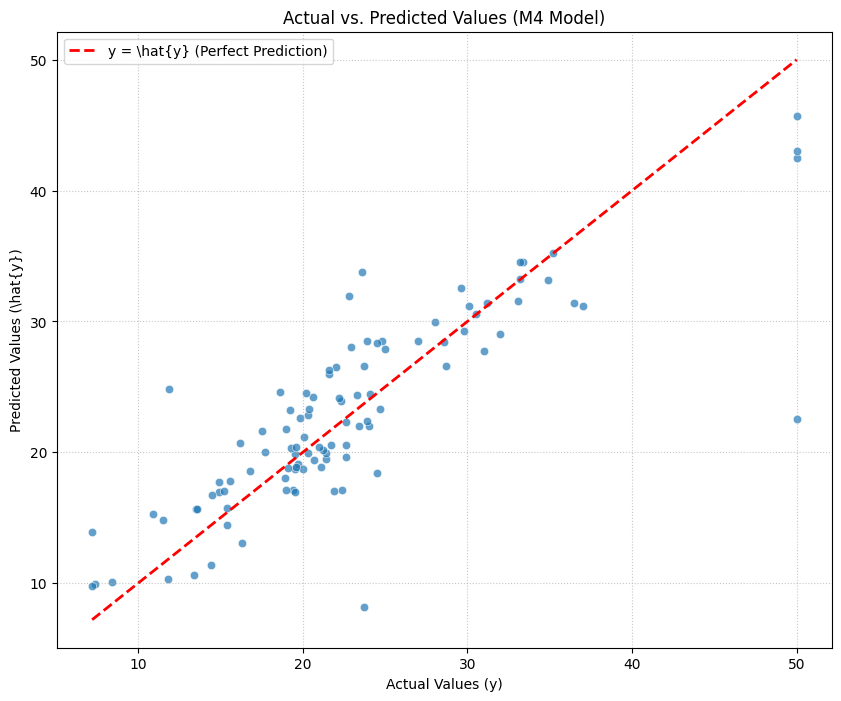

In [37]:
## (4-3) 최적 모형의 예측력 평가와 시각화
# (4-2)에서 선택한 최적 모형을 이용하여 실제 예측 성능을 평가하고, 예측모형으로서의 한계를 논의하시오.

#(a) 아래 기준에 따라 데이터를 훈련셋과 검증셋으로 분할하시오.
np.random.seed(42)
idx = np.random.permutation(len(boston_df))
train_idx = idx[:int(len(boston_df)*0.8)]
test_idx = idx[int(len(boston_df)*0.8):]
train = boston_df.iloc[train_idx]
test = boston_df.iloc[test_idx]

# (b) 최적 모형을 훈련셋으로만 추정하고, 검증셋에 대한 예측값(ŷ)을 계산하시오.
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# M4에 필요한 독립변수 행렬 생성
def get_X(df):
    X = df[['lstat', 'rm', 'age', 'crim', 'nox']].copy()
    X['lstat_rm'] = X['lstat'] * X['rm']
    return X

X_train = get_X(train)
y_train = train['medv']
X_test = get_X(test)
y_test = test['medv']

model = LinearRegression().fit(X_train, y_train)
y_hat = model.predict(X_test)

# (c) 검증셋에 대해 아래 지표를 직접 계산하여 출력하시오.
rmse = np.sqrt(mean_squared_error(y_test, y_hat))
mae = mean_absolute_error(y_test, y_hat)
r2_test = r2_score(y_test, y_hat)

print(f"RMSE: {rmse:.4f}, MAE: {mae:.4f}, Test R2: {r2_test:.4f}")

#(d) 실제값(y)을 가로축, 예측값(ŷ)을 세로축으로 하는 산포도를 그리시오. y = ŷ 인 대각선(45 도 직선)을빨간색으로 추가하고, 점들이 대각선에서 많이 벗어나는 구간(고가 주택 or 저가 주택)을 찾아서술하시오.
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=y_hat, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='y = \hat{y} (Perfect Prediction)')
plt.xlabel('Actual Values (y)')
plt.ylabel('Predicted Values (\hat{y})')
plt.title('Actual vs. Predicted Values (M4 Model)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

### 4-3 (d) 실제값(y)을 가로축, 예측값($\hat{y}$)을 세로축으로 하는 산포도를 그리시오. y = $\hat{y}$ 인 대각선(45 도 직선)을 빨간색으로 추가하고, 점들이 대각선에서 많이 벗어나는 구간(고가 주택 or 저가 주택)을 찾아 서술하시오.

산포도를 보면 대부분의 점들이 45도 대각선(y = $\hat{y}$) 주변에 밀집해 있어 모델의 예측력이 양호함을 알 수 있습니다. 하지만 특정 구간에서 점들이 대각선에서 벗어나는 경향을 보입니다.

*   **저가 주택 구간 (medv < 20-25 정도):** 실제 주택 가격이 낮은 구간에서는 예측값이 실제값보다 **과대평가(overestimated)**되는 경향이 있습니다. 즉, 모델은 저렴한 주택의 가격을 실제보다 높게 예측하는 경향을 보입니다. 점들이 대각선 위쪽에 위치한 것이 이 현상을 나타냅니다.

*   **고가 주택 구간 (medv > 40-45 정도):** 반대로 실제 주택 가격이 높은 구간에서는 예측값이 실제값보다 **과소평가(underestimated)**되는 경향이 있습니다. 모델은 비싼 주택의 가격을 실제보다 낮게 예측하는 경향을 보입니다. 이 구간의 점들은 대각선 아래쪽에 위치해 있습니다.

**해석:** 이러한 현상은 회귀 모델에서 흔히 나타나는 한계점 중 하나입니다. 모델은 데이터의 평균적인 관계를 학습하기 때문에, 데이터 분포의 양극단(특히 희소한 고가 또는 저가 주택)에서는 예측 정확도가 떨어질 수 있습니다. 이는 모델이 극단적인 값을 정확하게 예측하기 위해 필요한 정보(예: 더 많은 고가 주택 데이터, 특정 고급 시설 정보 등)가 부족하거나, 해당 구간의 데이터가 가지는 특성을 충분히 반영하지 못했기 때문일 수 있습니다. 이러한 편향은 모델의 예측을 실제 부동산 컨설팅에 활용할 때 주의가 필요함을 시사합니다.

### 4-3 (e) 훈련셋 R2와 검증셋 R2를 비교하고, 두 값의 차이가 크다면 그 원인을 Bias-Variance trade-off 관점에서 서술하시오. 또한 이 예측모형을 실제 부동산 컨설팅에 활용할 때의 한계점을 2 가지 이상 서술하시오.

**훈련셋 R2 (Adjusted R-squared):** M4 모델의 훈련셋에 대한 `Adj. R-squared`는 약 **0.702**입니다.
**검증셋 R2 (Test R2):** 검증셋에 대한 `Test R2`는 약 **0.6955**입니다.

**R2 값 비교 및 Bias-Variance Trade-off 관점:**

훈련셋 `Adj. R-squared` (0.702)와 검증셋 `Test R2` (0.6955)는 **매우 유사한 값**을 보입니다. 두 값의 차이가 매우 작다는 것은 모델이 훈련 데이터에 **과적합(overfitting)되지 않았다**는 긍정적인 신호입니다. 이는 모델이 훈련 데이터의 특이한 노이즈까지 학습하기보다는, 일반적인 데이터 패턴을 잘 포착하여 새로운 데이터(검증셋)에도 유사한 설명력을 보인다는 것을 의미합니다.

`Bias-Variance trade-off` 관점에서 보면:
*   **낮은 분산(Low Variance):** 훈련셋과 검증셋의 성능 차이가 적으므로, 모델의 분산(새로운 데이터에 대한 민감도)이 낮다고 평가할 수 있습니다. 즉, 이 모델은 특정 훈련 데이터셋에 지나치게 특화되지 않고 안정적으로 예측을 수행합니다.
*   **잔존하는 편향(Residual Bias):** 하지만 `Test R2`가 완벽하게 1이 아니라는 점, 그리고 (d)에서 확인했듯이 고가/저가 주택 구간에서 예측의 편향이 관찰된다는 점은 모델에 여전히 **어느 정도의 편향(bias)이 존재**함을 시사합니다. 이는 모델이 데이터에 내재된 복잡한 비선형 관계나 중요한 변수들을 아직 충분히 포착하지 못하고 있거나, 선형 모델의 한계 때문일 수 있습니다.

**실제 부동산 컨설팅 활용 시 한계점 (2가지 이상):**

이 예측 모형을 실제 부동산 컨설팅에 활용할 때 다음과 같은 한계점을 고려해야 합니다.

1.  **예측 불확실성과 신뢰 구간 부재:** 현재 모델은 점 추정(point prediction)만을 제공하며, 각 예측값에 대한 신뢰 구간(confidence interval)을 함께 제시하지 않습니다. 실제 컨설팅에서는 단순히 '가격이 얼마다'가 아니라 '가격이 얼마에서 얼마 사이일 확률이 높다'와 같은 정보가 의사결정에 훨씬 유용합니다. 신뢰 구간이 없으면 예측의 불확실성을 고려하기 어렵습니다.

2.  **새로운 시장 환경에 대한 일반화 능력 제한:** 보스턴 주택 데이터는 1978년의 특정 보스턴 지역 데이터를 기반으로 합니다. 이 모델은 급변하는 부동산 시장(금리 변동, 정책 변화, 신축 개발, 특정 트렌드 등)에 대한 예측력을 갖추기 어렵습니다. 또한, 다른 도시나 지역으로 모델을 확장 적용할 경우, 해당 지역의 고유한 특성(예: 문화, 교통 인프라, 지역 규제 등)이 반영되지 않아 예측 정확도가 크게 떨어질 수 있습니다. 모델이 학습한 환경 외의 새로운 환경에서는 예측력이 매우 제한적입니다.

3.  **결정 계층에서의 낮은 예측력:** (d)에서 분석했듯이, 모델은 특히 매우 비싸거나 매우 저렴한 주택의 가격을 과소/과대평가하는 경향이 있습니다. 실제 부동산 컨설팅에서는 고가 주택 또는 특정 니즈를 가진 저가 주택에 대한 정밀한 가격 예측이 중요한 경우가 많습니다. 이러한 극단적인 케이스에 대한 낮은 예측 정확도는 컨설팅의 신뢰성을 저해할 수 있습니다.

4.  **설명 변수의 한계:** 현재 사용된 변수들은 주택 가격에 영향을 미치는 주요 요인이지만, 실제 부동산 시장은 훨씬 더 많은 미시적이고 거시적인 요인(예: 내부 인테리어, 학군 세분화, 범죄율 변화, 지역 개발 계획 구체화, 재건축/재개발 가능성 등)에 의해 복합적으로 움직입니다. 이러한 변수들이 모델에 포함되지 않으면, 예측의 정확성과 설명력에 본질적인 한계가 있을 수밖에 없습니다.